In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

import numpy as np
from pixell import enmap, enplot, reproject
import glob
import matplotlib.pyplot as plt
import emcee, corner
from astropy.io import fits
import sys
from astropy import units as u, constants as const
sys.path.insert(0, '../src')
#sys.path.insert(0, "/home/gill/apps/szpack/python")
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
import yaml
import itertools
from pixell import enmap

import bandpass as bp
import covariance as cov
import model
import utils as ut

import SZpack as SZ

from astropy.coordinates import SkyCoord
import astropy.units as u

In [2]:
chain = "/home/gill/research/ACT/bridge/results/ajay/final_runs/case54/chain.h5"
sampler = emcee.backends.HDFBackend(chain)
samples = sampler.get_chain(discard=50000, flat=True, thin=1)

In [3]:
c1_tau = samples[:, 6]
c1_Te = samples[:, 7]
c1_v = samples[:, 9] * -1

c2_tau = samples[:, 16]
c2_Te = samples[:, 17]
c2_v = samples[:, 19] * -1

fil_tau = samples[:, 24]
fil_Te = samples[:, 25]
fil_v = samples[:, 27] * -1

Te_a401_mean = 8.47
Te_a401_std = 0.25

Te_a399_mean = 7.23
Te_a399_std = 0.19

Te_fil_mean = 6.52
Te_fil_std = 0.35

In [9]:
# change matplotlib font size and latex rendering
plt.rcParams.update({'font.size': 20})
plt.rcParams['text.usetex'] = 1 
# sans-serif font for latex
plt.rcParams['font.family'] = 'sans-serif'

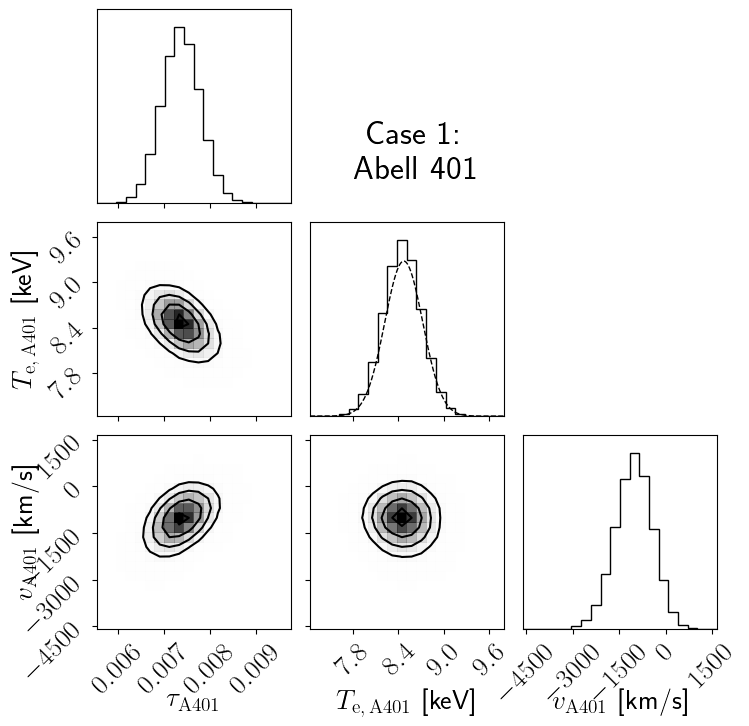

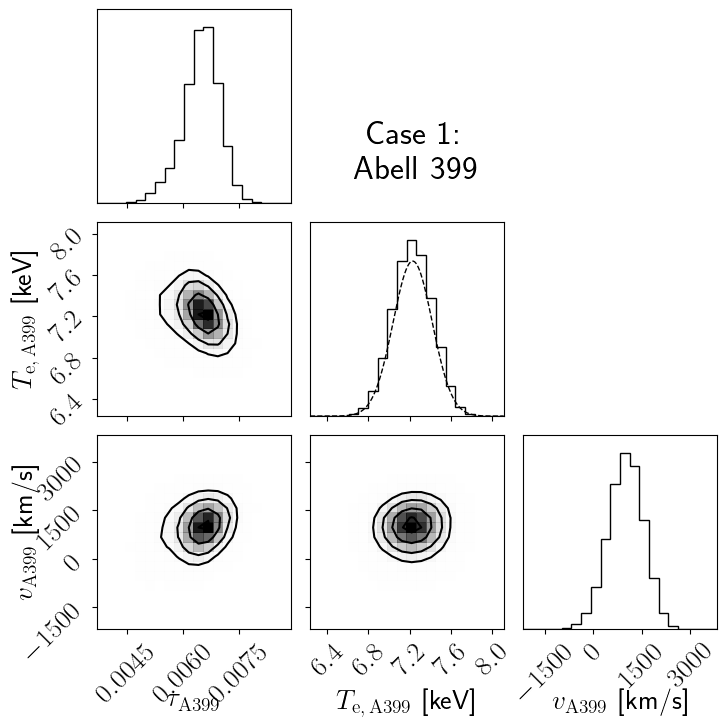

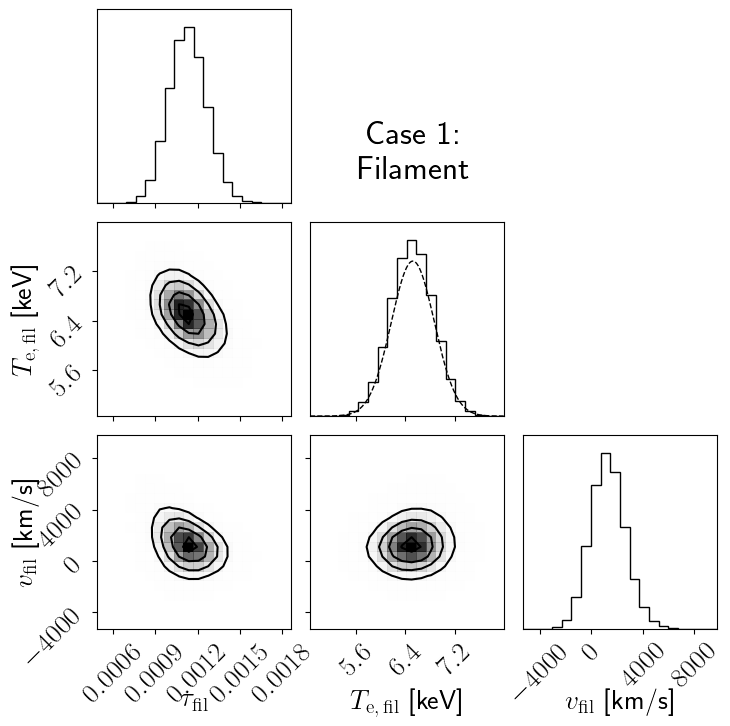

In [11]:
# Create corner plots for each component separately
fig1 = corner.corner(np.column_stack([c1_tau, c1_Te, c1_v]), 
                     labels=[r'$\tau_{\rm A401}$', r'$T_{\rm e, \, A401}$ [keV]', r'$v_{\rm A401}$ [km/s]'],
                     plot_datapoints=0,
                     show_titles=False)
fig1.suptitle('Case 1:\nAbell 401', fontsize=24, x=0.55, y=0.8)
fig1.subplots_adjust(hspace=0.1, wspace=0.1)

# Add Gaussian prior for Te_a401 on the temperature panel
axes = np.array(fig1.axes).reshape((3, 3))
ax_te = axes[1, 1]  # Temperature marginal plot (diagonal element)

# Create x values for the Gaussian
x_te = np.linspace(ax_te.get_xlim()[0], ax_te.get_xlim()[1], 1000)
gaussian_prior = (1/(Te_a401_std * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x_te - Te_a401_mean)/Te_a401_std)**2)

# Scale the Gaussian to match the histogram height
y_max = ax_te.get_ylim()[1]
gaussian_prior_scaled = gaussian_prior * y_max / np.max(gaussian_prior) * 0.8

# Plot the Gaussian prior
ax_te.plot(x_te, gaussian_prior_scaled, 'k--', linewidth=1, label='Prior')

fig2 = corner.corner(np.column_stack([c2_tau, c2_Te, c2_v]), 
                     labels=[r'$\tau_{\rm A399}$', r'$T_{\rm e, \, A399}$ [keV]', r'$v_{\rm A399}$ [km/s]'],
                     plot_datapoints=0,
                     show_titles=False)
fig2.suptitle('Case 1:\nAbell 399', fontsize=24, x=0.55, y=0.8)
fig2.subplots_adjust(hspace=0.1, wspace=0.1)

# Add Gaussian prior for Te_a399 on the temperature panel
axes = np.array(fig2.axes).reshape((3, 3))
ax_te = axes[1, 1]  # Temperature marginal plot (diagonal element)

# Create x values for the Gaussian
x_te = np.linspace(ax_te.get_xlim()[0], ax_te.get_xlim()[1], 1000)
gaussian_prior = (1/(Te_a399_std * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x_te - Te_a399_mean)/Te_a399_std)**2)

# Scale the Gaussian to match the histogram height
y_max = ax_te.get_ylim()[1]
gaussian_prior_scaled = gaussian_prior * y_max / np.max(gaussian_prior) * 0.8

# Plot the Gaussian prior
ax_te.plot(x_te, gaussian_prior_scaled, 'k--', linewidth=1, label='Prior')

fig3 = corner.corner(np.column_stack([fil_tau, fil_Te, fil_v]), 
                     labels=[r'$\tau_{\rm fil}$', r'$T_{\rm e, \, fil}$ [keV]', r'$v_{\rm fil}$ [km/s]'],
                     plot_datapoints=0,
                     show_titles=False)
fig3.suptitle('Case 1:\nFilament', fontsize=24, x=0.55, y=0.8)
fig3.subplots_adjust(hspace=0.1, wspace=0.1)

# Add Gaussian prior for Te_fil on the temperature panel
axes = np.array(fig3.axes).reshape((3, 3))
ax_te = axes[1, 1]  # Temperature marginal plot (diagonal element)

# Create x values for the Gaussian
x_te = np.linspace(ax_te.get_xlim()[0], ax_te.get_xlim()[1], 1000)
gaussian_prior = (1/(Te_fil_std * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x_te - Te_fil_mean)/Te_fil_std)**2)

# Scale the Gaussian to match the histogram height
y_max = ax_te.get_ylim()[1]
gaussian_prior_scaled = gaussian_prior * y_max / np.max(gaussian_prior) * 0.8

# Plot the Gaussian prior
ax_te.plot(x_te, gaussian_prior_scaled, 'k--', linewidth=1, label='Prior')

fig1.savefig('../plots/abell401_corner_tau_v_T_sep14.pdf', bbox_inches='tight', dpi=300)
fig2.savefig('../plots/abell399_corner_tau_v_T_sep14.pdf', bbox_inches='tight', dpi=300)
fig3.savefig('../plots/filament_corner_tau_v_T_sep14.pdf', bbox_inches='tight', dpi=300)

plt.show()

In [15]:
chain_case55 = "/home/gill/research/ACT/bridge/results/ajay/final_runs/case55/chain.h5"
sampler_case55 = emcee.backends.HDFBackend(chain_case55)
samples_case55 = sampler_case55.get_chain(discard=50000, flat=True, thin=1)

In [16]:
v_system_case55 = samples_case55[:, 25] 
tau_fil_case55 = samples_case55[:, 22]

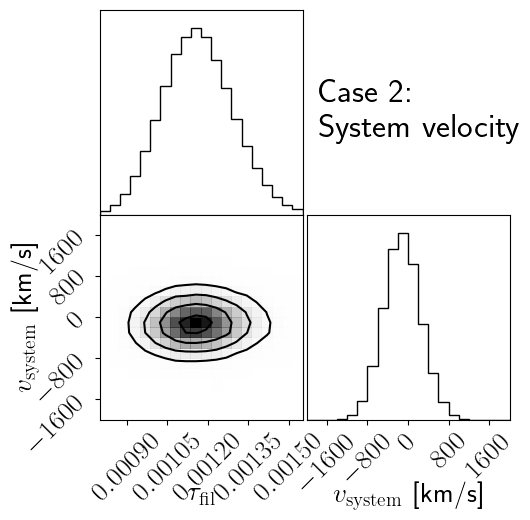

In [18]:
# corner plot of tau and v_system_case10
# latex font
plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif')
p_range = [(0.0008, 0.00155), (-2000, 2000)]

# font size
plt.rc('font', size=20)

data_case55 = np.column_stack([tau_fil_case55, v_system_case55])

fig = corner.corner(data_case55,
                    labels=[r'$\tau_{\rm fil}$', r'$v_{\rm system}$ [km/s]'],
                    plot_datapoints=0,
                    show_titles=0,
                    range=p_range,
                    title_fmt='.3f')
fig.suptitle('Case 2:\nSystem velocity', fontsize=24, x=0.58, y=0.8, ha="left")
fig.subplots_adjust(hspace=0., wspace=0.02)

fig.savefig('../plots/case2_corner_tau_v_sep14.pdf', bbox_inches='tight', dpi=300)
plt.show()


In [19]:
chain_case56 = "/home/gill/research/ACT/bridge/results/ajay/final_runs/case56/chain.h5"
sampler_case56 = emcee.backends.HDFBackend(chain_case56)
samples_case56 = sampler_case56.get_chain(discard=50000, flat=True, thin=1)

In [20]:
v_diff_case56 = samples_case56[:, 26] 
v_system_case56 = samples_case56[:, 25]

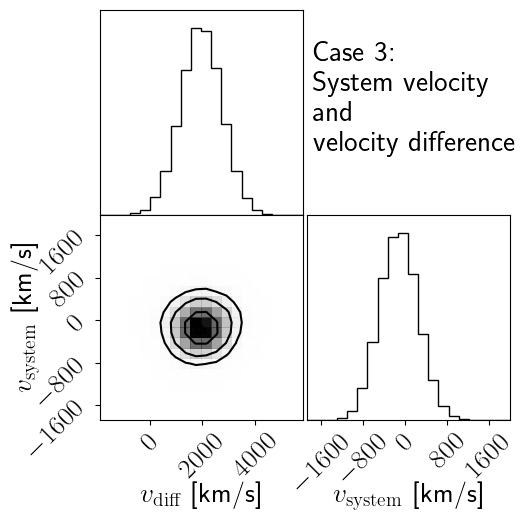

In [21]:
# corner plot for v_diff, and v_system
p_range = [(0.0008, 0.00155), (-1200, 2000)]

# font size
plt.rc('font', size=20)

data_case56 = np.column_stack([v_diff_case56, v_system_case56])

fig = corner.corner(data_case56,
                    labels=[r'$v_{\rm diff}$ [km/s]', r'$v_{\rm system}$ [km/s]'],
                    plot_datapoints=0,
                    show_titles=0,
                    title_fmt='.3f')
fig.suptitle('Case 3:\nSystem velocity \nand \nvelocity difference', fontsize=21, x=0.57, y=0.87, ha='left')
fig.subplots_adjust(hspace=0., wspace=0.02)

fig.savefig('../plots/case3_corner_v_diff_v_system_sep14.pdf', bbox_inches='tight', dpi=300)
plt.show()
